In [1]:
from dotenv import load_dotenv
load_dotenv()

True

# State

In [2]:
import operator
from typing import Sequence, TypedDict, Annotated, List, Tuple, Literal

from langchain_core.messages import BaseMessage

In [3]:
class InputData(BaseMessage):
    variable_name: str
    data_path: str
    data_description: str

In [4]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    input_data: Annotated[List[InputData], operator.add]
    intermediate_outputs: Annotated[List[dict], operator.add]
    current_variables: dict
    output_image_paths: Annotated[List[str], operator.add]

# Tools

In [5]:
import sys
from io import StringIO

from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool
from langgraph.prebuilt import InjectedState

In [6]:
repl = PythonREPL()
persistent_vars = {}

@tool(parse_docstring=True)
def complete_python_task(
    graph_state: Annotated[dict, InjectedState],
    thought: str,
    python_code: str
) -> Tuple[str, dict]:
    """
    Completes a Python task by executing the provided code.

    Args:
        graph_state (dict): The state of the graph.
        thought (str): The thought process leading to this code.
        python_code (str): The Python code to execute.
    """
    current_vars = graph_state["current_variables"] if "current_variables" in graph_state else {}

    try:
        # capture standard output
        old_stdout = sys.stdout
        sys.stdout = StringIO()

        # execute the code and capture the result
        exec_globals = globals().copy()
        exec_globals.update(persistent_vars)
        exec_globals.update(current_vars)
        exec_globals.update({"plotly_figures": []})

        exec(python_code, exec_globals)
        persistent_vars.update({
            k:v for k, v in exec_globals.items() if k not in globals()
        })

        # get the captured output
        output = sys.stdout.getvalue()

        # restore stdout
        sys.stdout = old_stdout

        #update
        updated_state = {
            "intermediate_outputs": [{"thought": thought, "code": python_code, "output": output}],
            "current_variables": persistent_vars
        }

        return output, updated_state

    except Exception as e:
        return str(e), {"intermediate_outputs": [{"thought": thought, "code": python_code, "output": str(e)}]}

# Node

In [7]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

In [8]:
# load prompt
with open("./main_prompt.md", "r") as f:
    prompt = f.read()

In [9]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

model = llm.bind_tools(tools=[complete_python_task])

chat_template = ChatPromptTemplate.from_messages([
    ("system", prompt),
    ("placeholder", "{messages}"),
])

# chain
model = chat_template | model 

In [10]:
def create_data_summary(state: AgentState) -> str:
    """
    
    """
    summary = ""
    variables = []

    for data in state["input_data"]:
        variables.append(data["variable"])
        summary += f"\n\nVariable: {data['variable_name']}"
        summary += f"Description: {data['data_description']}"

    if "current_variables" in state:
        remaining_vars = [v for v in state["currrent_variables"] if v not in variables]
        for v in remaining_vars:
            summary += f"\n\Variable: {v}"
    
    return summary


def call_model(state: AgentState):
    """
    
    """
    current_data_template = """The following data is available:\n{data_summary}"""
    current_data_message = HumanMessage(
        content=current_data_template.format(data_summary=create_data_summary(state))
    )
    state["messages"] = [current_data_message] + state["messages"]

    llm_response = model.invoke(state)

    return {
        "messages": [llm_response],
        "intermediate_outputs": [current_data_message.content],
    }

In [11]:
def route_to_tools(state: AgentState) -> Literal["tools", "__end__"]:
    """
    
    """
    if messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages in state: {state}")
    
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"

In [12]:
tools = [complete_python_task]

def call_tools(state: AgentState):
    """
    
    """
    last_message = state["messages"][-1]
    tool_messages = []
    state_updates = {}

    if isinstance(last_message, AIMessage) and hasattr(last_message, "tool_calls"):
        for tc in last_message.tool_calls:
            tool_name = tc["name"]
            tool_input = tc["args"]

            tool = next((t for t in tools if t.name == tool_name), None)
            if tool is None:
                raise ValueError(f"Tool {tool_name} not found")
            
            # invoke the tool with the provided input and graph_state
            result = tool.invoke({**tool_input, "graph_state": state})
            message, updates = result
            tool_messages.append(
                ToolMessage(
                    content=str(message),
                    name=tool_name,
                    tool_call_id=tc["id"]
                )
            )
            state_updates.update(updates)

    state_updates["messages"] = tool_messages
    return state_updates

# graph

In [14]:
from langgraph.graph import StateGraph

In [23]:
class AgentVisualizer:
    def __init__(self):
        super().__init__()

        self.reset_chat()
        self.graph = self.create_graph()

    def create_graph(self):
        workflow = StateGraph(AgentState)

        workflow.add_node("llm", call_model)
        workflow.add_node("tools", call_tools)

        workflow.add_conditional_edges("llm", route_to_tools)
        workflow.add_edge("tools", "llm")

        workflow.set_entry_point("llm")
        return workflow.compile()
    
    def reset_chat(self):
        self.chat_history = []
        self.intermediate_outputs = []

In [24]:
agent = AgentVisualizer()

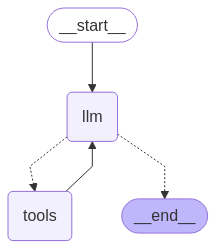

In [25]:
agent.graph

In [28]:
input_state = {
    "messages": [] + [HumanMessage(content="i provide you no data. i want you to create a plot of the sine function using dummy data")],
}

result = agent.graph.invoke(input_state, {"recursion_limit": 25})
result["messages"]

KeyError: 'currrent_variables'